# Accessing the Selection Function

With this codebase, you have direct result to the selection function. It is calculated on the fly based on the input data file, which is some set of 100 pc stars observed in SDSS-V, the user suppled selection function bins and the Gaia Catalog of Nearby Star data.

In [1]:
from snc_sf.selection_function import SNCSelectionFunction
import matplotlib.pylab as plt
import os
import numpy as np
import polars as pl
%matplotlib inline
plt.style.use('%s/mystyle.mplstyle' % os.environ['MPL_STYLES'])


MG_bin_list = [0, 20, 0.25]

sf_bins={'healpix': 3,
         'phot_g_mean_mag': [0, 20.5, 0.5],
         'g_rp': [-0.4, 2.2, 0.05]}

n_g_rp = len(np.arange(*sf_bins['g_rp'])) - 1
n_mg = len(np.arange(*MG_bin_list)) - 1



data_file = 'obs_100pc_edr3.csv'

# initilize
mean = True
sncsf = SNCSelectionFunction(data_file, sf_bins, MG_bin_list, mean=mean)


/Users/imedan/miniforge3/envs/snc_sf_forward/lib/python3.11/site-packages/gaiaunlimited/selectionfunctions/apogee.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


The below shows how to access the bins that the grid is calculated on. Within the polars dataframe for the subsample, these bin indexes are already calculated, such that they are esier to query and calculate selection probabilites. The below code does this for each bin in $G$ and $G-RP$ for different regions on the sky.

In [2]:
Gbins = np.arange(*sncsf.sf_bins['phot_g_mean_mag'])

GRPbins = np.arange(*sncsf.sf_bins['g_rp'])



In [3]:
from snc_sf.utils import calc_subsample_p

RNG = np.random.default_rng(666)


median_cmd = np.zeros((len(GRPbins), len(Gbins)))

for i in range(len(GRPbins)):
    for j in range(len(Gbins)):
        idx = np.where((np.array(sncsf.subsamp['g_rp_']) == i) & (np.array(sncsf.subsamp['phot_g_mean_mag_']) == j))[0]
        if len(idx) > 0:
            if np.nansum(sncsf.subsamp['k'][idx]) > 0:
                samps = calc_subsample_p(
                                np.zeros(1000) + np.nansum(sncsf.subsamp['k'][idx]),
                                np.zeros(1000) + np.nansum(sncsf.subsamp['n'][idx]),
                                RNG)
                median_cmd[i][j] = np.median(samps)
        else:
            median_cmd[i][j] = np.nan

In [4]:
import astropy.coordinates as coord
import astropy.units as u
import healpy as hp

nside = hp.order2nside(sncsf.sf_bins['healpix'])
npix = hp.order2npix(sncsf.sf_bins['healpix'])
ipix = np.arange(npix)
ra, dec = hp.pix2ang(nside, ipix, lonlat=True, nest=True)
sc = coord.SkyCoord(ra * u.deg, dec * u.deg)

In [5]:
median_cmd_lowlat = np.zeros((len(GRPbins), len(Gbins)))

for i in range(len(GRPbins)):
    for j in range(len(Gbins)):
        idx = np.where((np.isin(sncsf.subsamp['healpix_'], ipix[abs(sc.galactic.b.deg) < 10])) \
                       & (np.array(sncsf.subsamp['g_rp_']) == i) \
                       & (np.array(sncsf.subsamp['phot_g_mean_mag_']) == j))[0]
        if len(idx) > 0:
            if np.nansum(sncsf.subsamp['k'][idx]) > 0:
                samps = calc_subsample_p(
                                np.zeros(1000) + np.nansum(sncsf.subsamp['k'][idx]),
                                np.zeros(1000) + np.nansum(sncsf.subsamp['n'][idx]),
                                RNG)
                median_cmd_lowlat[i][j] = np.median(samps)
        else:
            median_cmd_lowlat[i][j] = np.nan


In [6]:
median_cmd_highlat = np.zeros((len(GRPbins), len(Gbins)))

for i in range(len(GRPbins)):
    for j in range(len(Gbins)):
        idx = np.where((np.isin(sncsf.subsamp['healpix_'], ipix[abs(sc.galactic.b.deg) > 55])) \
                       & (np.array(sncsf.subsamp['g_rp_']) == i) \
                       & (np.array(sncsf.subsamp['phot_g_mean_mag_']) == j))[0]
        if len(idx) > 0:
            if np.nansum(sncsf.subsamp['k'][idx]) > 0:
                samps = calc_subsample_p(
                                np.zeros(1000) + np.nansum(sncsf.subsamp['k'][idx]),
                                np.zeros(1000) + np.nansum(sncsf.subsamp['n'][idx]),
                                RNG)
                median_cmd_highlat[i][j] = np.median(samps)
        else:
            median_cmd_highlat[i][j] = np.nan


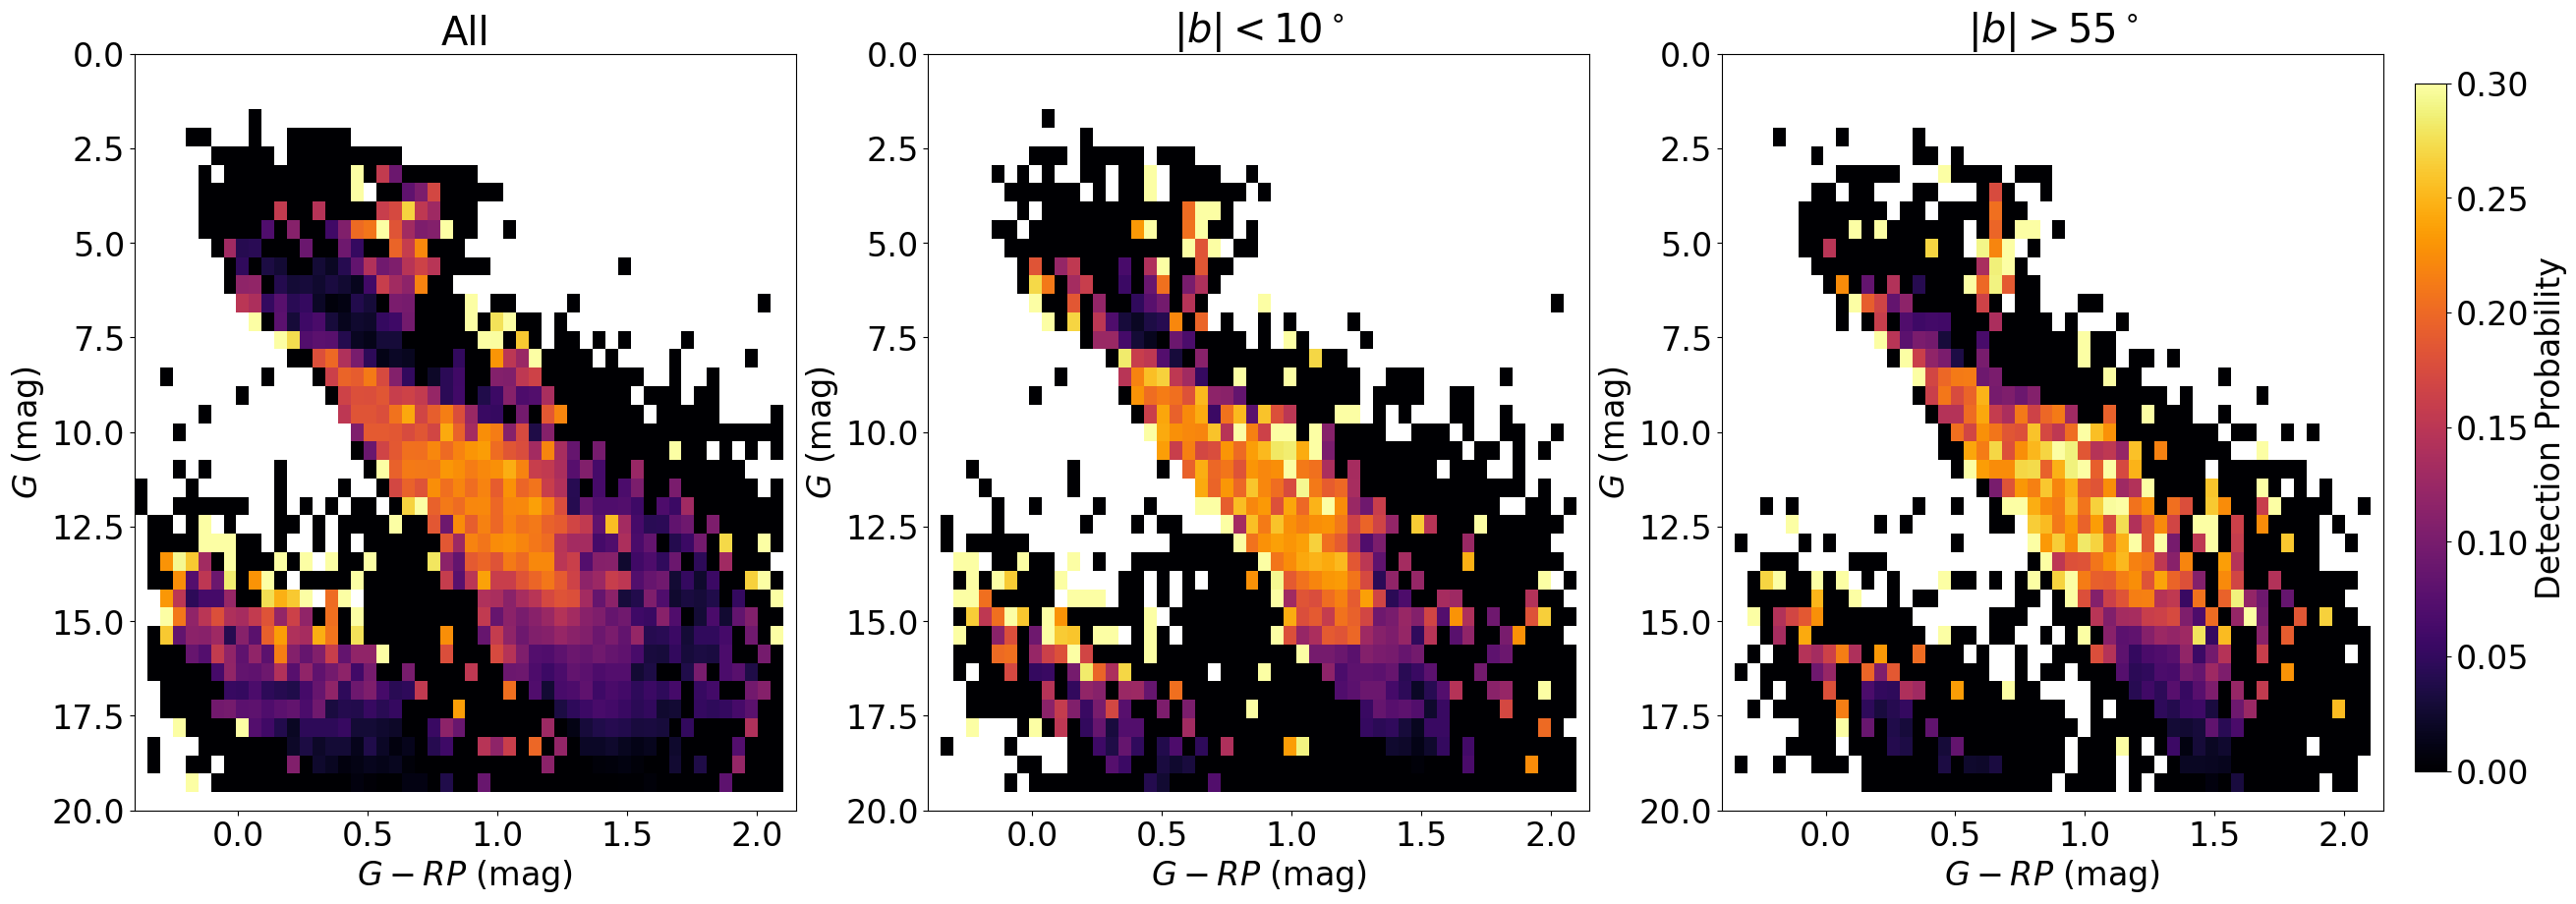

In [7]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(32, 10))

ax1.imshow(median_cmd.T, origin='lower', aspect='auto',
           extent=(GRPbins.min(), GRPbins.max(), Gbins.min(), Gbins.max()), vmin=0., vmax=0.3, cmap='inferno')
ax1.set_title('All')

ax2.imshow(median_cmd_lowlat.T, origin='lower', aspect='auto',
           extent=(GRPbins.min(), GRPbins.max(), Gbins.min(), Gbins.max()), vmin=0., vmax=0.3, cmap='inferno')
ax2.set_title(r'$|b| < 10^\circ$')

dens = ax3.imshow(median_cmd_highlat.T, origin='lower', aspect='auto',
           extent=(GRPbins.min(), GRPbins.max(), Gbins.min(), Gbins.max()), vmin=0., vmax=0.3, cmap='inferno')
ax3.set_title(r'$|b| > 55^\circ$')

for ax in [ax1, ax2, ax3]:
    ax.invert_yaxis()
    ax.set_xlabel(r'$G-RP$ (mag)')
    ax.set_ylabel(r'$G$ (mag)')

f.subplots_adjust(right=0.84)
cbar_ax = f.add_axes([0.85, 0.15, 0.01, 0.7])
f.colorbar(dens, cax=cbar_ax, label=r'Detection Probability')

plt.savefig('paper_plots/CMD_detection_prob.png', bbox_inches='tight')

plt.show()
